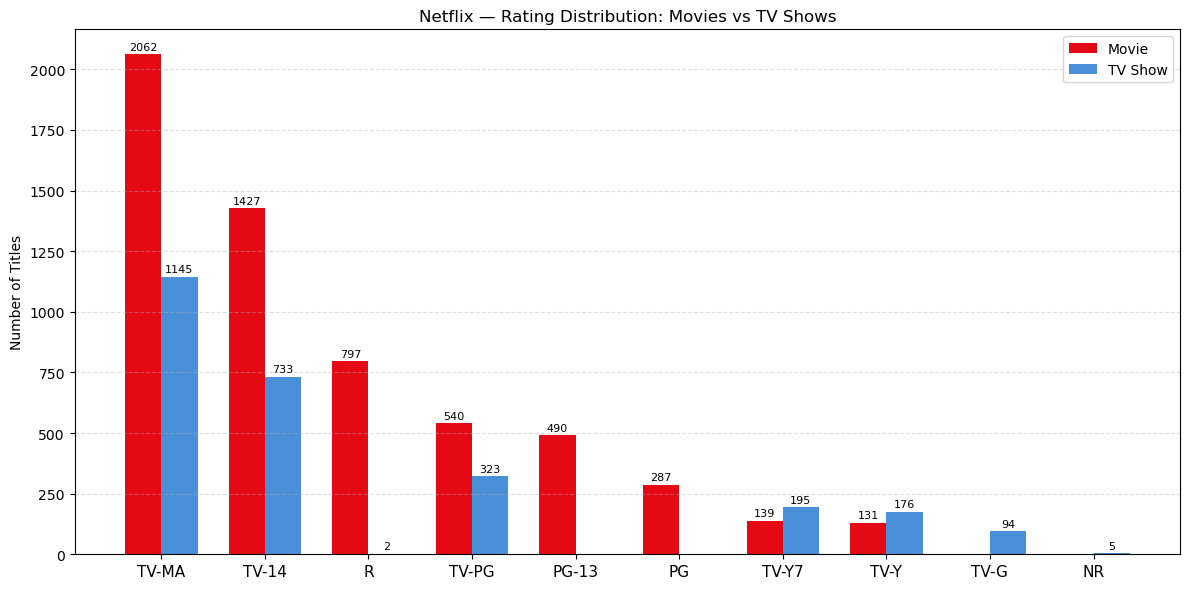

Top rating — Movies  : TV-MA (2062 titles)
Top rating — TV Shows: TV-MA (1145 titles)


In [3]:
"""
Netflix Rating Distribution: Movies vs TV Shows

OBJECTIVE:
Netflix uses different ratings for Movies (MPAA: G, PG, R…)
and TV Shows (TV-G, TV-14, TV-MA…). This EDA compares how
ratings are distributed across both content types.

PSEUDOCODE:
1. Load CSV
2. Clean missing/bad ratings
3. Split into Movies and TV Shows
4. Count ratings per type
5. Plot grouped bar chart
6. Print top rating for each type
"""

import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv("netflix_titles.csv")

# 2. Clean ratings
df = df[~df["rating"].str.contains(r"\d+ min", na=False)]  # remove bad rows
df["rating"] = df["rating"].fillna("Not Rated")

# 3. Split by type
movies = df[df["type"] == "Movie"]
tv     = df[df["type"] == "TV Show"]

# 4. Count top 8 ratings per type
movie_counts = movies["rating"].value_counts().head(8)
tv_counts    = tv["rating"].value_counts().head(8)

# Align both on the same rating labels
all_labels = list(dict.fromkeys(movie_counts.index.tolist() + tv_counts.index.tolist()))
movie_vals = [movie_counts.get(r, 0) for r in all_labels]
tv_vals    = [tv_counts.get(r, 0)    for r in all_labels]

# 5. Plot
x     = range(len(all_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar([i - width/2 for i in x], movie_vals, width, label="Movie",   color="#E50914")
bars2 = ax.bar([i + width/2 for i in x], tv_vals,    width, label="TV Show", color="#4A90D9")

ax.set_xticks(list(x))
ax.set_xticklabels(all_labels, fontsize=11)
ax.set_ylabel("Number of Titles")
ax.set_title("Netflix — Rating Distribution: Movies vs TV Shows")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Add value labels on bars
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 10,
                str(int(h)), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("netflix_rating_simple.png", dpi=150)
plt.show()

# 6. Print insights
print("Top rating — Movies  :", movie_counts.idxmax(), f"({movie_counts.max()} titles)")
print("Top rating — TV Shows:", tv_counts.idxmax(),    f"({tv_counts.max()} titles)")